In [71]:
import numpy as np
import pylab as plt
import pyccl as ccl
import pyccl.nl_pt as pt
import pyccl.ccllib as lib
from astropy import units as u
from astropy.coordinates import Angle
%pylab inline 
from astropy.table import Table

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


# Preliminaries
Setting up a cosmology and defining the redshift distribution

In [64]:
#cosmo_SLICS cosmo table:
cosmo_par = np.loadtxt('cosmoTable.dat', usecols=[1,2,3,4])

Om = cosmo_par[:,0]
S8 = cosmo_par[:,1]
h  = cosmo_par[:,2]
w0 = cosmo_par[:,3]

In [65]:
def GetNz(filename,zcut_flag):
    print("Reading N(z)")

    nzs=np.loadtxt(filename, unpack = True)
    #nzs=np.loadtxt(filename, unpack = True)
    nbins=np.shape(nzs)[0] -1
    z=nzs[0]
    nzs_s=nzs[1:]
    #z=nzs_HACC[0,0,:]
    #nzs_s=nzs_HACC[:,1,:]
    print("Nbins = ",nbins)
    if(zcut_flag):
        for i in range(len(nzs_s)):
            nzs_s[i][np.where(z>3.0)]=0

    for i in range(len(nzs_s)):
        plot(z,nzs_s[i])

    return z, nzs_s, nbins

Reading N(z)
Nbins =  5


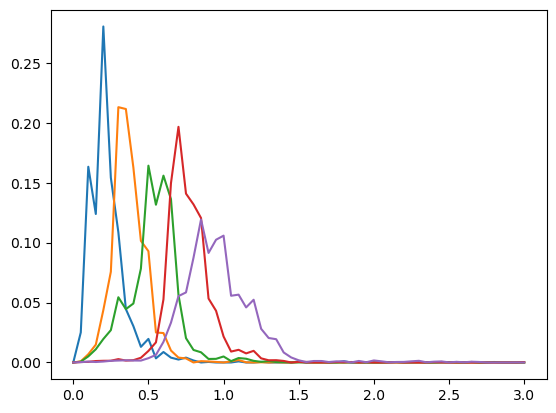

In [66]:
#zcut_flag = True;zcut_str = '_zcut'
zcut_flag = False;zcut_str = ''
#z, nzs_s, nbins = GetNz("./nz_KiDS-Legacy_6bins.dat",zcut_flag)
z, nzs_s, nbins = GetNz("./nz_KiDS1000_cut.dat",zcut_flag)

In [67]:
# Biases for IAs. Will be converted to the input c_IA values below.
a_1 = 1.0
a_2 = 0.0
a_d = 1.0

In [68]:
names=('NO IA+','NO IA-','GI+','GI-','GI_NLA+','GI_NLA-','II+','II-','II_NLA+','II_NLA-','theta', 'bin_comb' )
index=[]
for i in range(nbins):
    for j in range(i+1):
        index.append([i+1,j+1])
index=np.stack(index)

In [70]:
# Loop over cosmology:
Omega_b=0.0447

for cosmo_id in range(0,26):
    print('cosmo', str(cosmo_id),Om[cosmo_id], S8[cosmo_id], h[cosmo_id], w0[cosmo_id])
    
    sigma8=S8[cosmo_id]*np.sqrt(0.3/Om[cosmo_id])
    cosmo = ccl.Cosmology(Omega_c=Om[cosmo_id]-Omega_b, Omega_b=Omega_b, 
    h=h[cosmo_id], sigma8 = sigma8, n_s= 0.969,w0=w0[cosmo_id],wa=0.0, Omega_k=0.0)

    #IA tracers:
    c_1,c_d,c_2 = pt.translate_IA_norm(cosmo, z=z,a1=a_1,a2=a_2, a1delta=a_d, Om_m2_for_c2 = False)

    # Intrinsic alignments
    ptt_i = pt.PTIntrinsicAlignmentTracer(c1=(z,c_1), c2=(z,c_2), cdelta=(z,c_d))
    ptt_i_nla = pt.PTIntrinsicAlignmentTracer(c1=(z,c_1)) # to compare using the standard WLTracer
    
    # Matter
    ptt_m = pt.PTMatterTracer()

    #emulator_mt = ccl.CosmicemuMTIVPk("tot")  # nonlinear power spectrum emulator for CosmicEmu (Mira-Titan IV)
    #cosmology_dm = ccl.CosmologyVanillaLCDM(matter_power_spectrum=emulator_mt)  # cosmology object
    #pk_dm = cosmology_dm.nonlin_matter_power(k, a)  # dark matter only power spectrum

    
    #Perturbation theory:
    ptc = pt.EulerianPTCalculator(with_NC=True, with_IA=True,
                      log10k_min=-5, log10k_max=3, low_extrap=-5, high_extrap=5, nk_per_decade=20)

    ptc.update_ingredients(cosmo)

    # IAs x IAs
    pk_ii = ptc.get_biased_pk2d(ptt_i, tracer2=ptt_i) 
    pk_ii_bb = ptc.get_biased_pk2d(ptt_i, tracer2=ptt_i, return_ia_bb=True)
    pk_ii_nla = ptc.get_biased_pk2d(ptt_i_nla, tracer2=ptt_i_nla)
    
    # IAs x matter
    pk_im = ptc.get_biased_pk2d(ptt_i, tracer2=ptt_m)
    
    # Matter x matter
    pk_mm = ptc.get_biased_pk2d(ptt_m, tracer2=ptt_m)

    # Lensing ell-space:
    tracers_len = []
    
    for i in range(len(nzs_s)):
        t_l = ccl.WeakLensingTracer(cosmo, dndz=(z, nzs_s[i]))
        tracers_len.append(t_l)
    
    
    # Intrinsic alignments
    tracers_IA = []
    for i in range(len(nzs_s)):
        t_i = ccl.WeakLensingTracer(cosmo, dndz=(z, nzs_s[i]), has_shear=False, ia_bias=(z, np.ones_like(z)), use_A_ia=False)
        tracers_IA.append(t_i)
    
    # Intrinsic alignments
    tracers_IA_nla = []
    for i in range(len(nzs_s)):
        t_i_nla = ccl.WeakLensingTracer(cosmo, dndz=(z, nzs_s[i]), has_shear=False, ia_bias=(z, np.ones_like(z)), use_A_ia=True)
        tracers_IA_nla.append(t_i_nla)
    
    ell = np.unique(np.geomspace(2,300000,10000).astype(int)).astype(float)
    cls={}
    
    
    cross=[]
    for i in range(len(nzs_s)):
        for j in range(i+1):
            cross.append(ccl.angular_cl(cosmo, tracers_len[i], tracers_len[j], ell))
    cls['GG'] = np.stack(cross)
    
    cross=[]
    for i in range(len(nzs_s)):
        for j in range(i+1):
            cross.append(ccl.angular_cl(cosmo, tracers_IA[i], tracers_IA[j], ell,p_of_k_a=pk_ii))
    cls['II'] = np.stack(cross)
    
    cross=[]
    for i in range(len(nzs_s)):
        for j in range(i+1):
            cross.append(ccl.angular_cl(cosmo, tracers_IA_nla[i], tracers_IA_nla[j], ell))
    cls['II,NLA'] = np.stack(cross)
    
    
    cross=[]
    for i in range(len(nzs_s)):
        for j in range(i+1):
            cross.append(ccl.angular_cl(cosmo, tracers_len[i],tracers_IA[j], ell, p_of_k_a=pk_im))
    cls['GI'] =np.stack(cross)
    
    
    cross=[]
    for i in range(len(nzs_s)):
        for j in range(i+1):
            cross.append(ccl.angular_cl(cosmo, tracers_len[i],tracers_IA_nla[j], ell))
    cls['GI,NLA'] =np.stack(cross)


    # Lensing theta-space, in arcmin:
    #KiDS-Legacy, LSST and Euclid:
    #theta=np.geomspace(0.5,450,20)

    #KiDS-1000:
    theta=[7.836655555555556152e-01,1.597244444444444467e+00,3.252249999999999641e+00,6.621738888888889285e+00,1.349572222222222173e+01,2.743677777777777749e+01,5.564944444444443405e+01,1.124388888888888829e+02,2.214388888888888971e+02]
    
    theta_arc=Angle(theta,u.arcmin)
    
    theta=theta_arc.deg
    
    shear_GG_plus=[]
    for i in range(int(nbins*(nbins+1)/2)): 
        shear_GG_plus.append(ccl.correlation(cosmo, ell=ell, C_ell=cls['GG'][i], theta=theta ,type = 'GG+', method='FFTLog'))
    shear_GG_plus=np.stack(shear_GG_plus)
    
    shear_GG_minus=[]
    for i in range(int(nbins*(nbins+1)/2)): 
        shear_GG_minus.append(ccl.correlation(cosmo, ell=ell, C_ell=cls['GG'][i], theta=theta, type = 'GG-', method='FFTLog'))
    shear_GG_minus=np.stack(shear_GG_minus)
    
    shear_II_NLA_plus=[]
    for i in range(int(nbins*(nbins+1)/2)): 
        shear_II_NLA_plus.append(ccl.correlation(cosmo, ell=ell,C_ell=cls['II,NLA'][i] ,theta=theta , type = 'GG+', method='FFTLog'))
    shear_II_NLA_plus=np.stack(shear_II_NLA_plus)
    
    shear_II_NLA_minus=[]
    for i in range(int(nbins*(nbins+1)/2)): 
        shear_II_NLA_minus.append(ccl.correlation(cosmo, ell=ell,C_ell=cls['II,NLA'][i] ,theta=theta , type = 'GG-', method='FFTLog'))
    shear_II_NLA_minus=np.stack(shear_II_NLA_minus)
    
    shear_II_plus=[]
    for i in range(int(nbins*(nbins+1)/2)): 
        shear_II_plus.append(ccl.correlation(cosmo, ell=ell,C_ell=cls['II'][i] ,theta=theta , type = 'GG+', method='FFTLog'))
    shear_II_plus=np.stack(shear_II_plus)
    
    shear_II_minus=[]
    for i in range(int(nbins*(nbins+1)/2)): 
        shear_II_minus.append(ccl.correlation(cosmo, ell=ell,C_ell=cls['II'][i] ,theta=theta , type = 'GG-', method='FFTLog'))
    shear_II_minus=np.stack(shear_II_minus)
    
    shear_GI_plus=[]
    for i in range(int(nbins*(nbins+1)/2)): 
        shear_GI_plus.append(ccl.correlation(cosmo, ell=ell,C_ell=cls['GI'][i] ,theta=theta , type = 'GG+', method='FFTLog'))
    shear_GI_plus=np.stack(shear_GI_plus)
    
    shear_GI_minus=[]
    for i in range(int(nbins*(nbins+1)/2)): 
        shear_GI_minus.append(ccl.correlation(cosmo, ell=ell,C_ell=cls['GI'][i] ,theta=theta , type = 'GG-', method='FFTLog'))
    shear_GI_minus=np.stack(shear_GI_minus)
    
    shear_GI_NLA_plus=[]
    for i in range(int(nbins*(nbins+1)/2)): 
        shear_GI_NLA_plus.append(ccl.correlation(cosmo, ell=ell,C_ell=cls['GI,NLA'][i] ,theta=theta , type = 'GG+', method='FFTLog'))
    shear_GI_NLA_plus=np.stack(shear_GI_NLA_plus)
    
    shear_GI_NLA_minus=[]
    for i in range(int(nbins*(nbins+1)/2)): 
        shear_GI_NLA_minus.append(ccl.correlation(cosmo, ell=ell,C_ell=cls['GI,NLA'][i] ,theta=theta ,type = 'GG-',method='FFTLog'))
    shear_GI_NLA_minus=np.stack(shear_GI_NLA_minus)


    thetax=[]
    for i in range(len(shear_GG_plus)):
        thetax.append(theta)
    
    theta=np.stack(thetax)

    #--------------------------------
    # Save in fits-format files:
    t = Table([shear_GG_plus,shear_GG_minus, shear_GI_plus,shear_GI_minus,shear_GI_NLA_plus,shear_GI_NLA_minus,shear_II_plus,shear_II_minus,shear_II_NLA_plus,shear_II_NLA_minus,theta,np.stack(index)], names=names)
    t.write('theory/CCL/KiDS-1000/theo_prediction_KiDS-1000_cosmo'+str(cosmo_id)+'_a1_p1.0_bta_1.0_a2_0.0'+zcut_str+'.fits', format='fits', overwrite=True)
    #t.write('theory/CCL/KiDS-Legacy/theo_prediction_KiDS-Legacy_cosmo'+str(cosmo_id)+'_a1_p1.0_bta_1.0_a2_0.0'+zcut_str+'.fits', format='fits', overwrite=True)


cosmo 0 0.3282 0.6984 0.6766 -1.2376
cosmo 1 0.1019 0.7826 0.7104 -1.6154
cosmo 2 0.2536 0.6133 0.6238 -1.7698
cosmo 3 0.1734 0.7284 0.6584 -0.5223
cosmo 4 0.3759 0.8986 0.6034 -0.9741
cosmo 5 0.4758 0.7618 0.7459 -1.3046
cosmo 6 0.1458 0.768 0.8031 -1.4498
cosmo 7 0.3099 0.7861 0.694 -1.8784
cosmo 8 0.4815 0.6804 0.6374 -0.7737
cosmo 9 0.3425 0.7054 0.8006 -1.501
cosmo 10 0.5482 0.6375 0.7645 -1.9127
cosmo 11 0.2898 0.7218 0.6505 -0.6649
cosmo 12 0.4247 0.7511 0.6819 -1.1986
cosmo 13 0.3979 0.8476 0.7833 -1.1088
cosmo 14 0.1691 0.8618 0.789 -1.6903
cosmo 15 0.1255 0.6131 0.7567 -0.9878
cosmo 16 0.5148 0.8178 0.6691 -1.3812
cosmo 17 0.1928 0.8862 0.6285 -0.8564
cosmo 18 0.2784 0.65 0.7151 -1.0673
cosmo 19 0.2106 0.8759 0.7388 -0.5667
cosmo 20 0.443 0.8356 0.6161 -1.7037
cosmo 21 0.4062 0.662 0.8129 -1.9866
cosmo 22 0.2294 0.8226 0.7706 -0.8602
cosmo 23 0.5095 0.7366 0.6988 -0.7164
cosmo 24 0.3652 0.6574 0.7271 -1.5414
cosmo 25 0.2905 0.8231 0.6898 -1.0


# Tracers
Let's create the 3 PTTracers

In [92]:
# with_NC (bool) – set to True if you’ll want to use this calculator to compute correlations involving number counts.
# with_IA (bool) – set to True if you’ll want to use this calculator to compute correlations involving intrinsic alignments.

# ptc = pt.PTCalculator(with_NC=True, with_IA=True,
#                       log10k_min=-5, log10k_max=3, low_extrap=-5, high_extrap=3, nk_per_decade=20)


# PT power spectra

Now we need to initialize the ptc object, i.e. essentially precomputing some of the stuff it needs to get you PT power spectra.

# Angular power spectra

In [102]:
def trim_axs(axs, N):
    """
    Reduce *axs* to *N* Axes. All further Axes are removed from the figure.
    """
    axs = axs.flat
    for ax in axs[N:]:
        ax.remove()
        plt.xlabel(r'$\theta$', fontsize=15)
        plt.ylabel(r'$\xi_+(\theta)$', fontsize=15)
    return axs[:N]

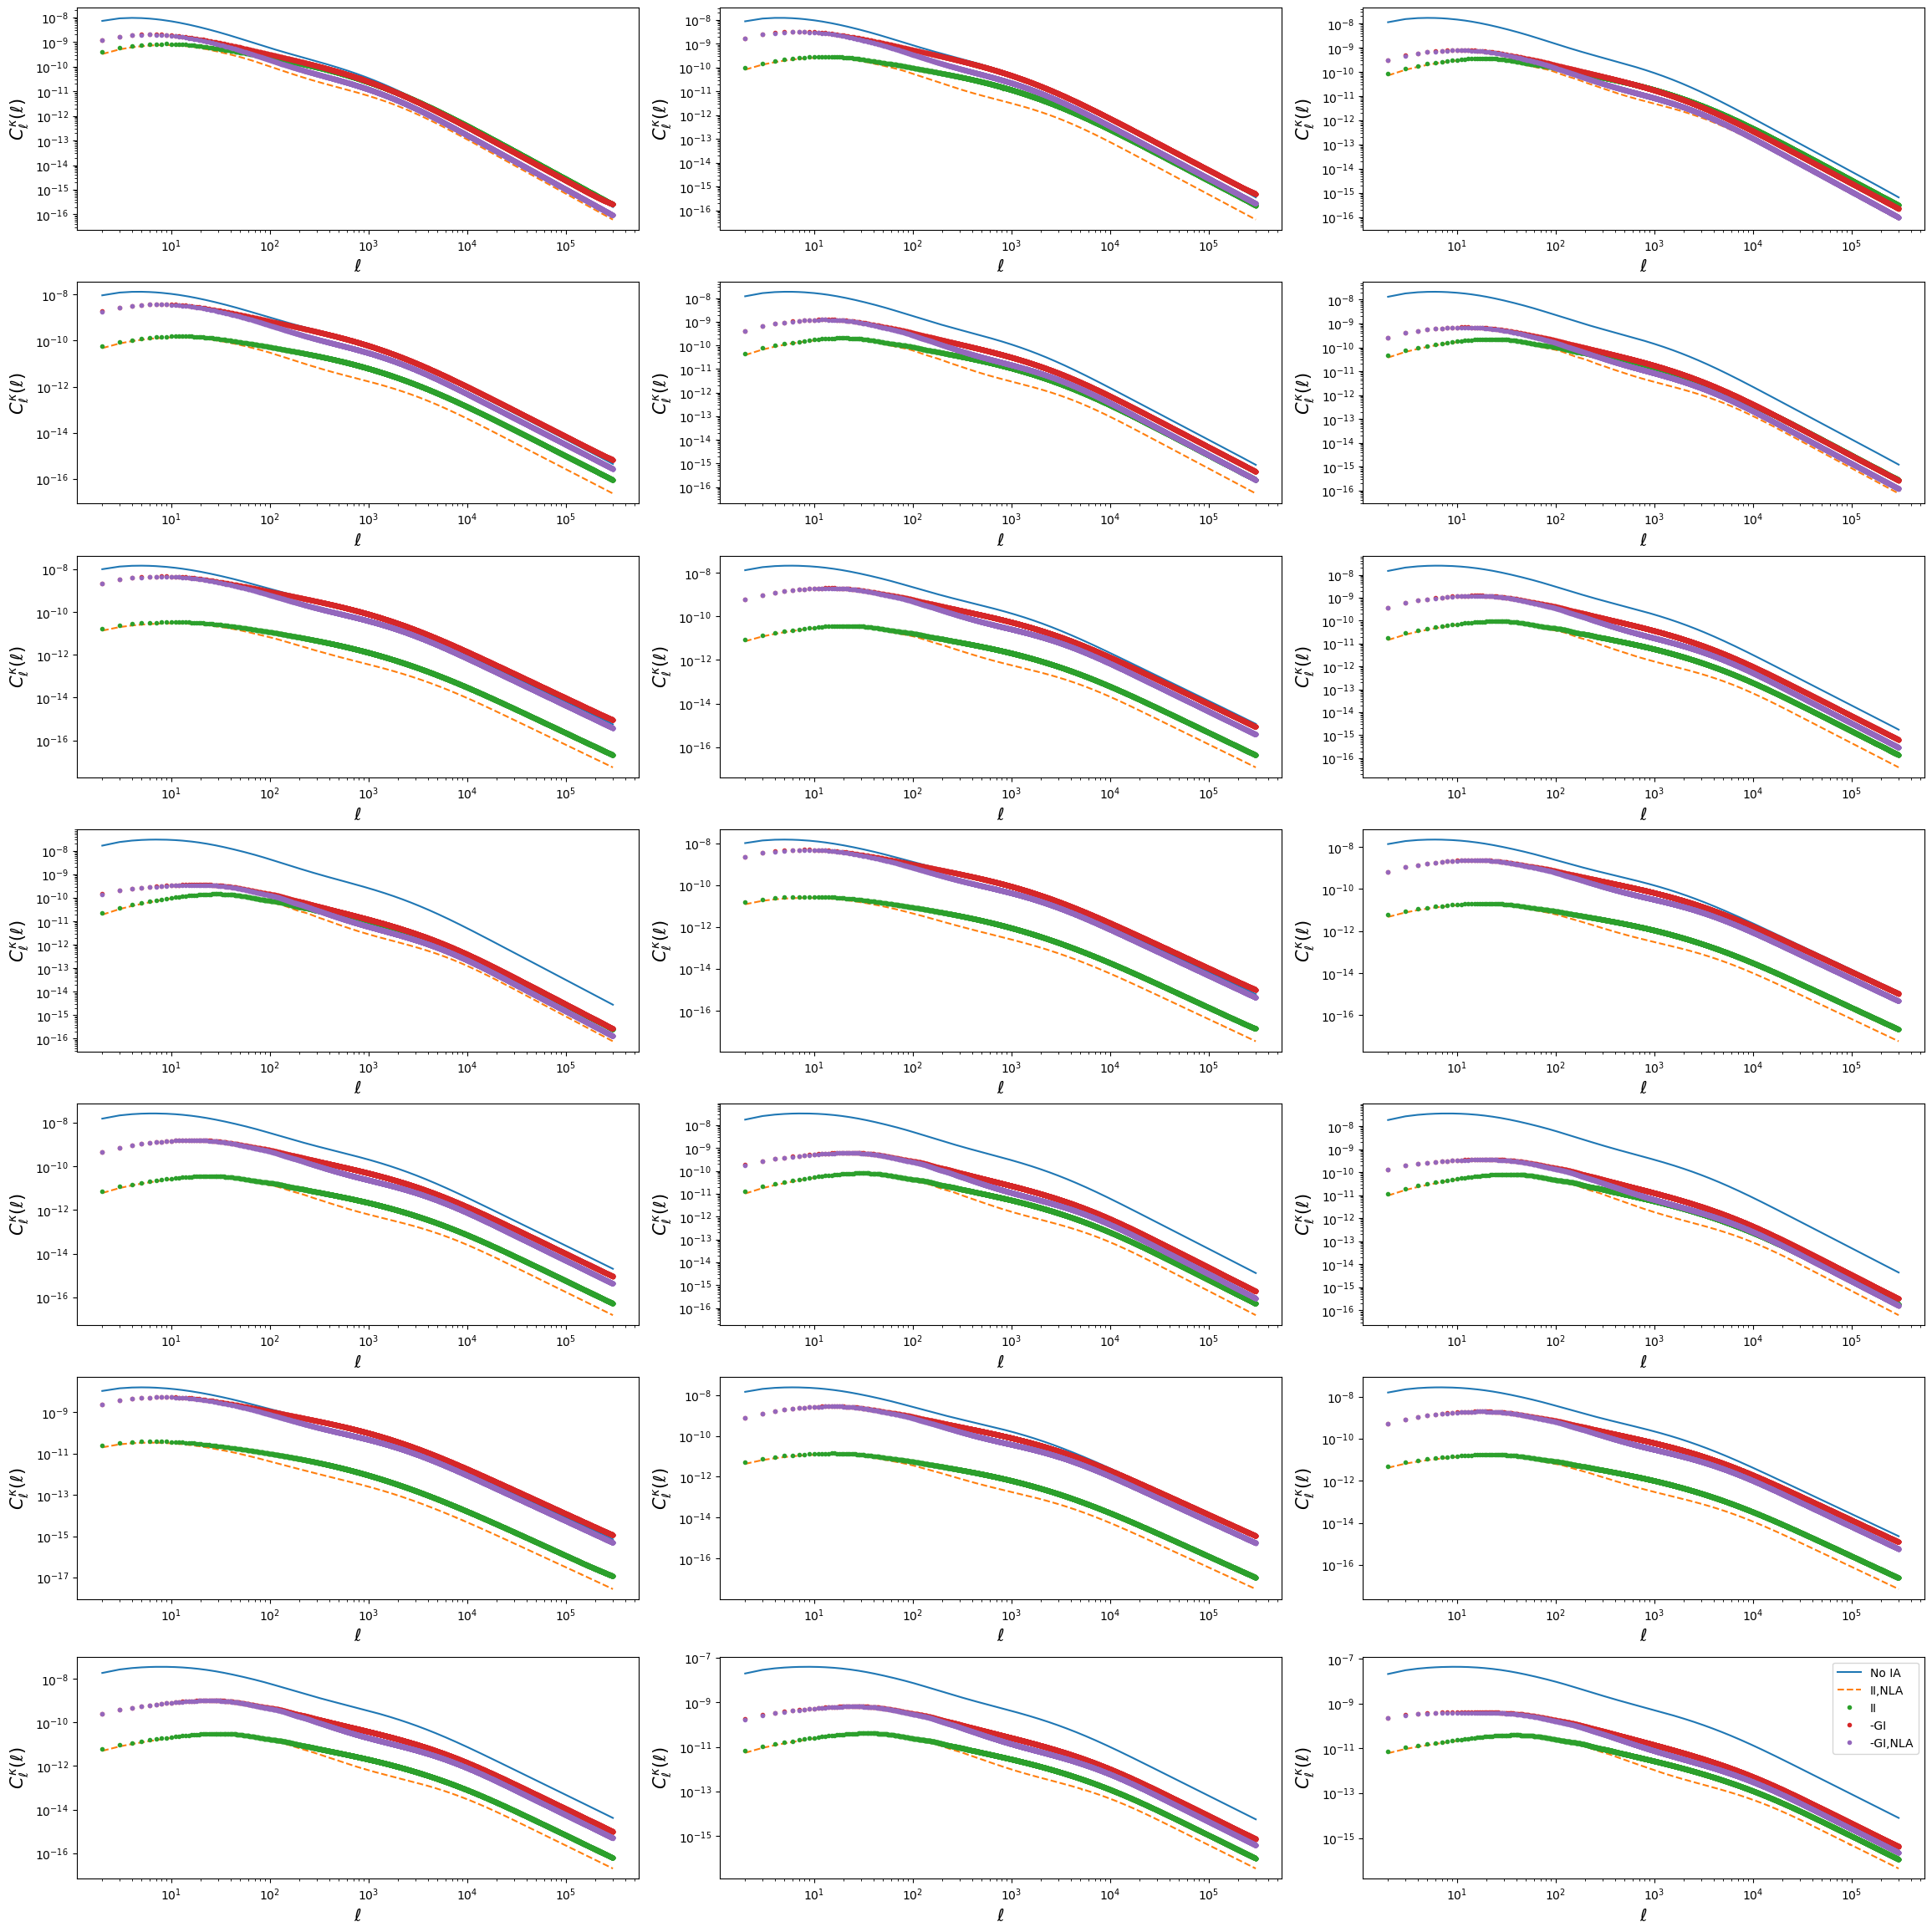

In [103]:
k=ell
figsize = (23, 23)
fig =plt.figure(figsize=figsize, constrained_layout=True)
cols = 3
rows =len(nzs_s)+1
axs = fig.subplots(rows, cols)
axs = trim_axs(axs, len(cls['GG']))
for ax, pi in zip(axs, cls['GG']):
    ax.loglog(ell, pi,label='No IA')
for ax, px in zip(axs, cls['II,NLA']):
    ax.loglog(ell, px,'--',label='II,NLA')
for ax, pj in zip(axs, cls['II']):
    ax.loglog(ell, pj,'.',label='II')
for ax, pjk in zip(axs, cls['GI']):
    ax.loglog(ell,-pjk,'.',label='-GI')
for ax, pjj in zip(axs, cls['GI,NLA']):
    ax.loglog(ell, -pjj,'.',label='-GI,NLA')
    ax.set_xlabel(r'$\ell$', fontsize=15)
    ax.set_ylabel(r'$C^{\kappa}_{\ell}(\ell)$', fontsize=15)
    
legend(loc='upper right')

# Shear correlation function

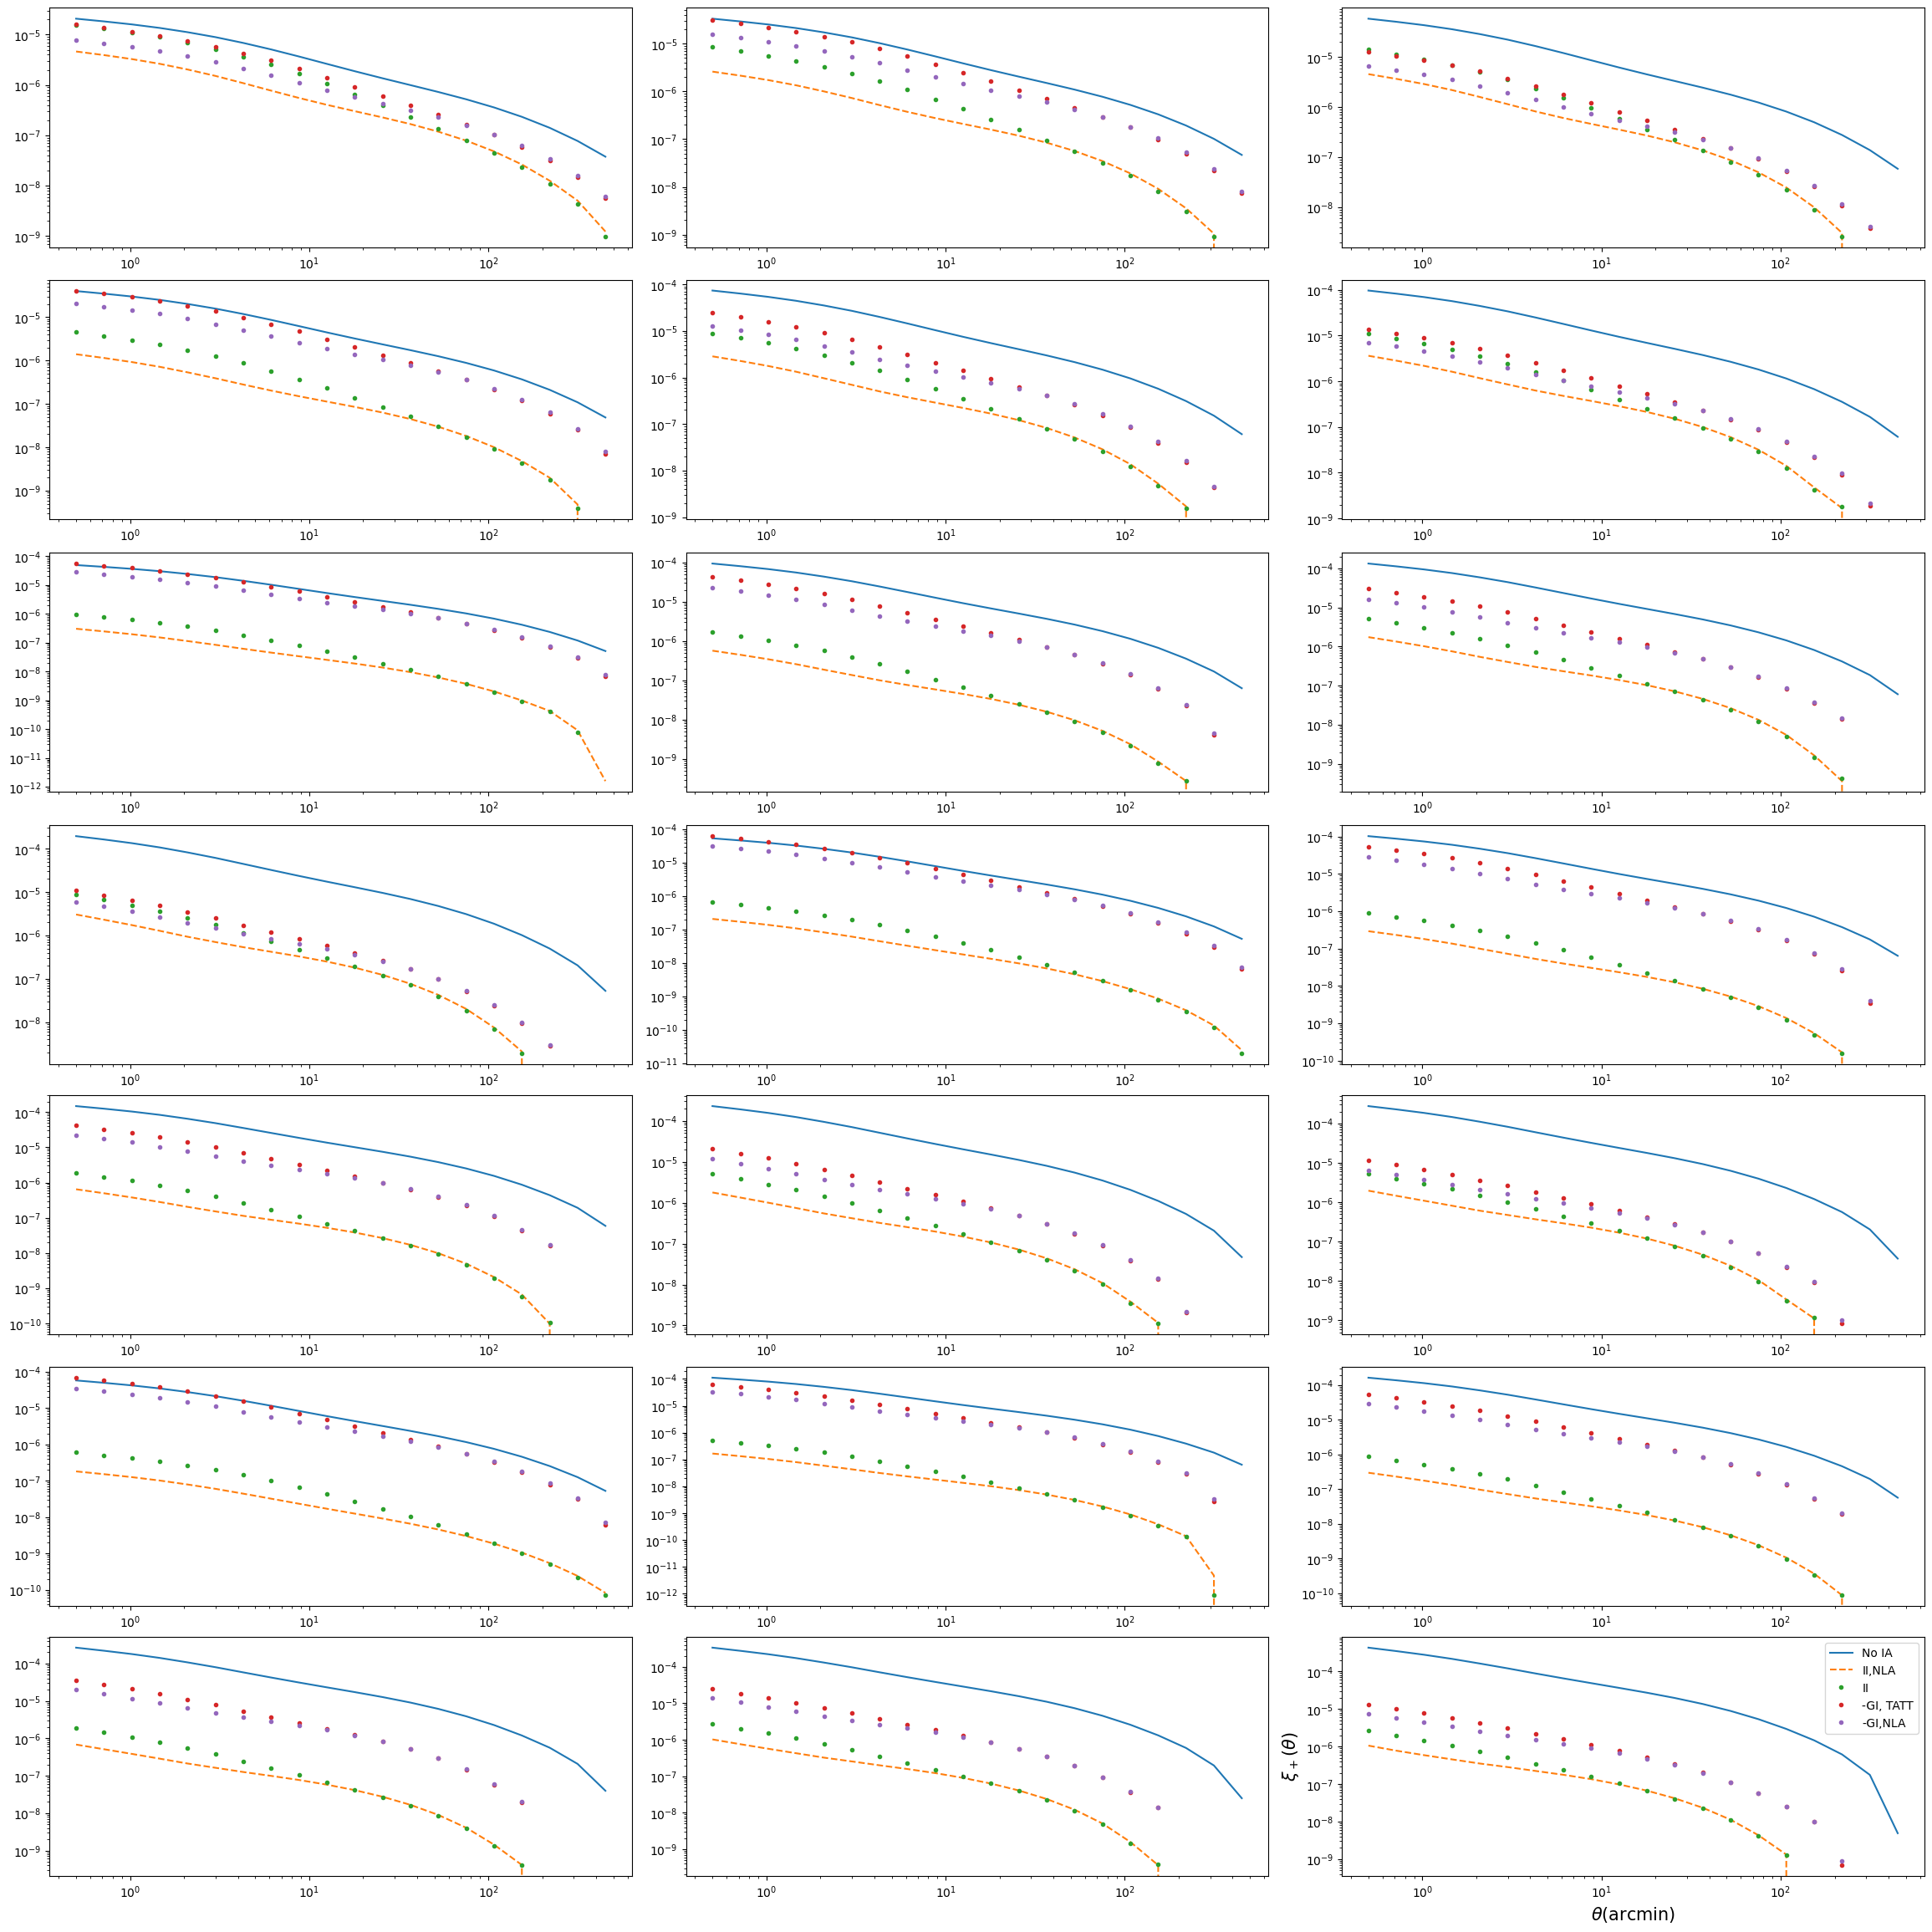

In [117]:
figsize = (23, 23)
fig =plt.figure(figsize=figsize, constrained_layout=True)
cols = 3
rows =nbins+1
axs = fig.subplots(rows, cols)
axs = trim_axs(axs, len(shear_GG_plus))
for ax, pi in zip(axs, shear_GG_plus):
    ax.loglog(theta_arc, pi,label='No IA')
for ax, px in zip(axs, shear_II_NLA_plus):
    ax.loglog(theta_arc, px,'--',label='II,NLA')
for ax, pj in zip(axs, shear_II_plus):
    ax.loglog(theta_arc, pj,'.',label='II')
for ax, pjk in zip(axs, shear_GI_plus):
    ax.loglog(theta_arc,-pjk,'.',label='-GI, TATT')
for ax, pjj in zip(axs, shear_GI_NLA_plus):
    ax.loglog(theta_arc, -pjj,'.',label='-GI,NLA')
    plt.xlabel(r'$\theta$(arcmin)', fontsize=15)
    plt.ylabel(r'$\xi_+(\theta)$', fontsize=15)
xlim()
legend(loc='upper right')
#fig.savefig("pos_cross.png",dpi=250)

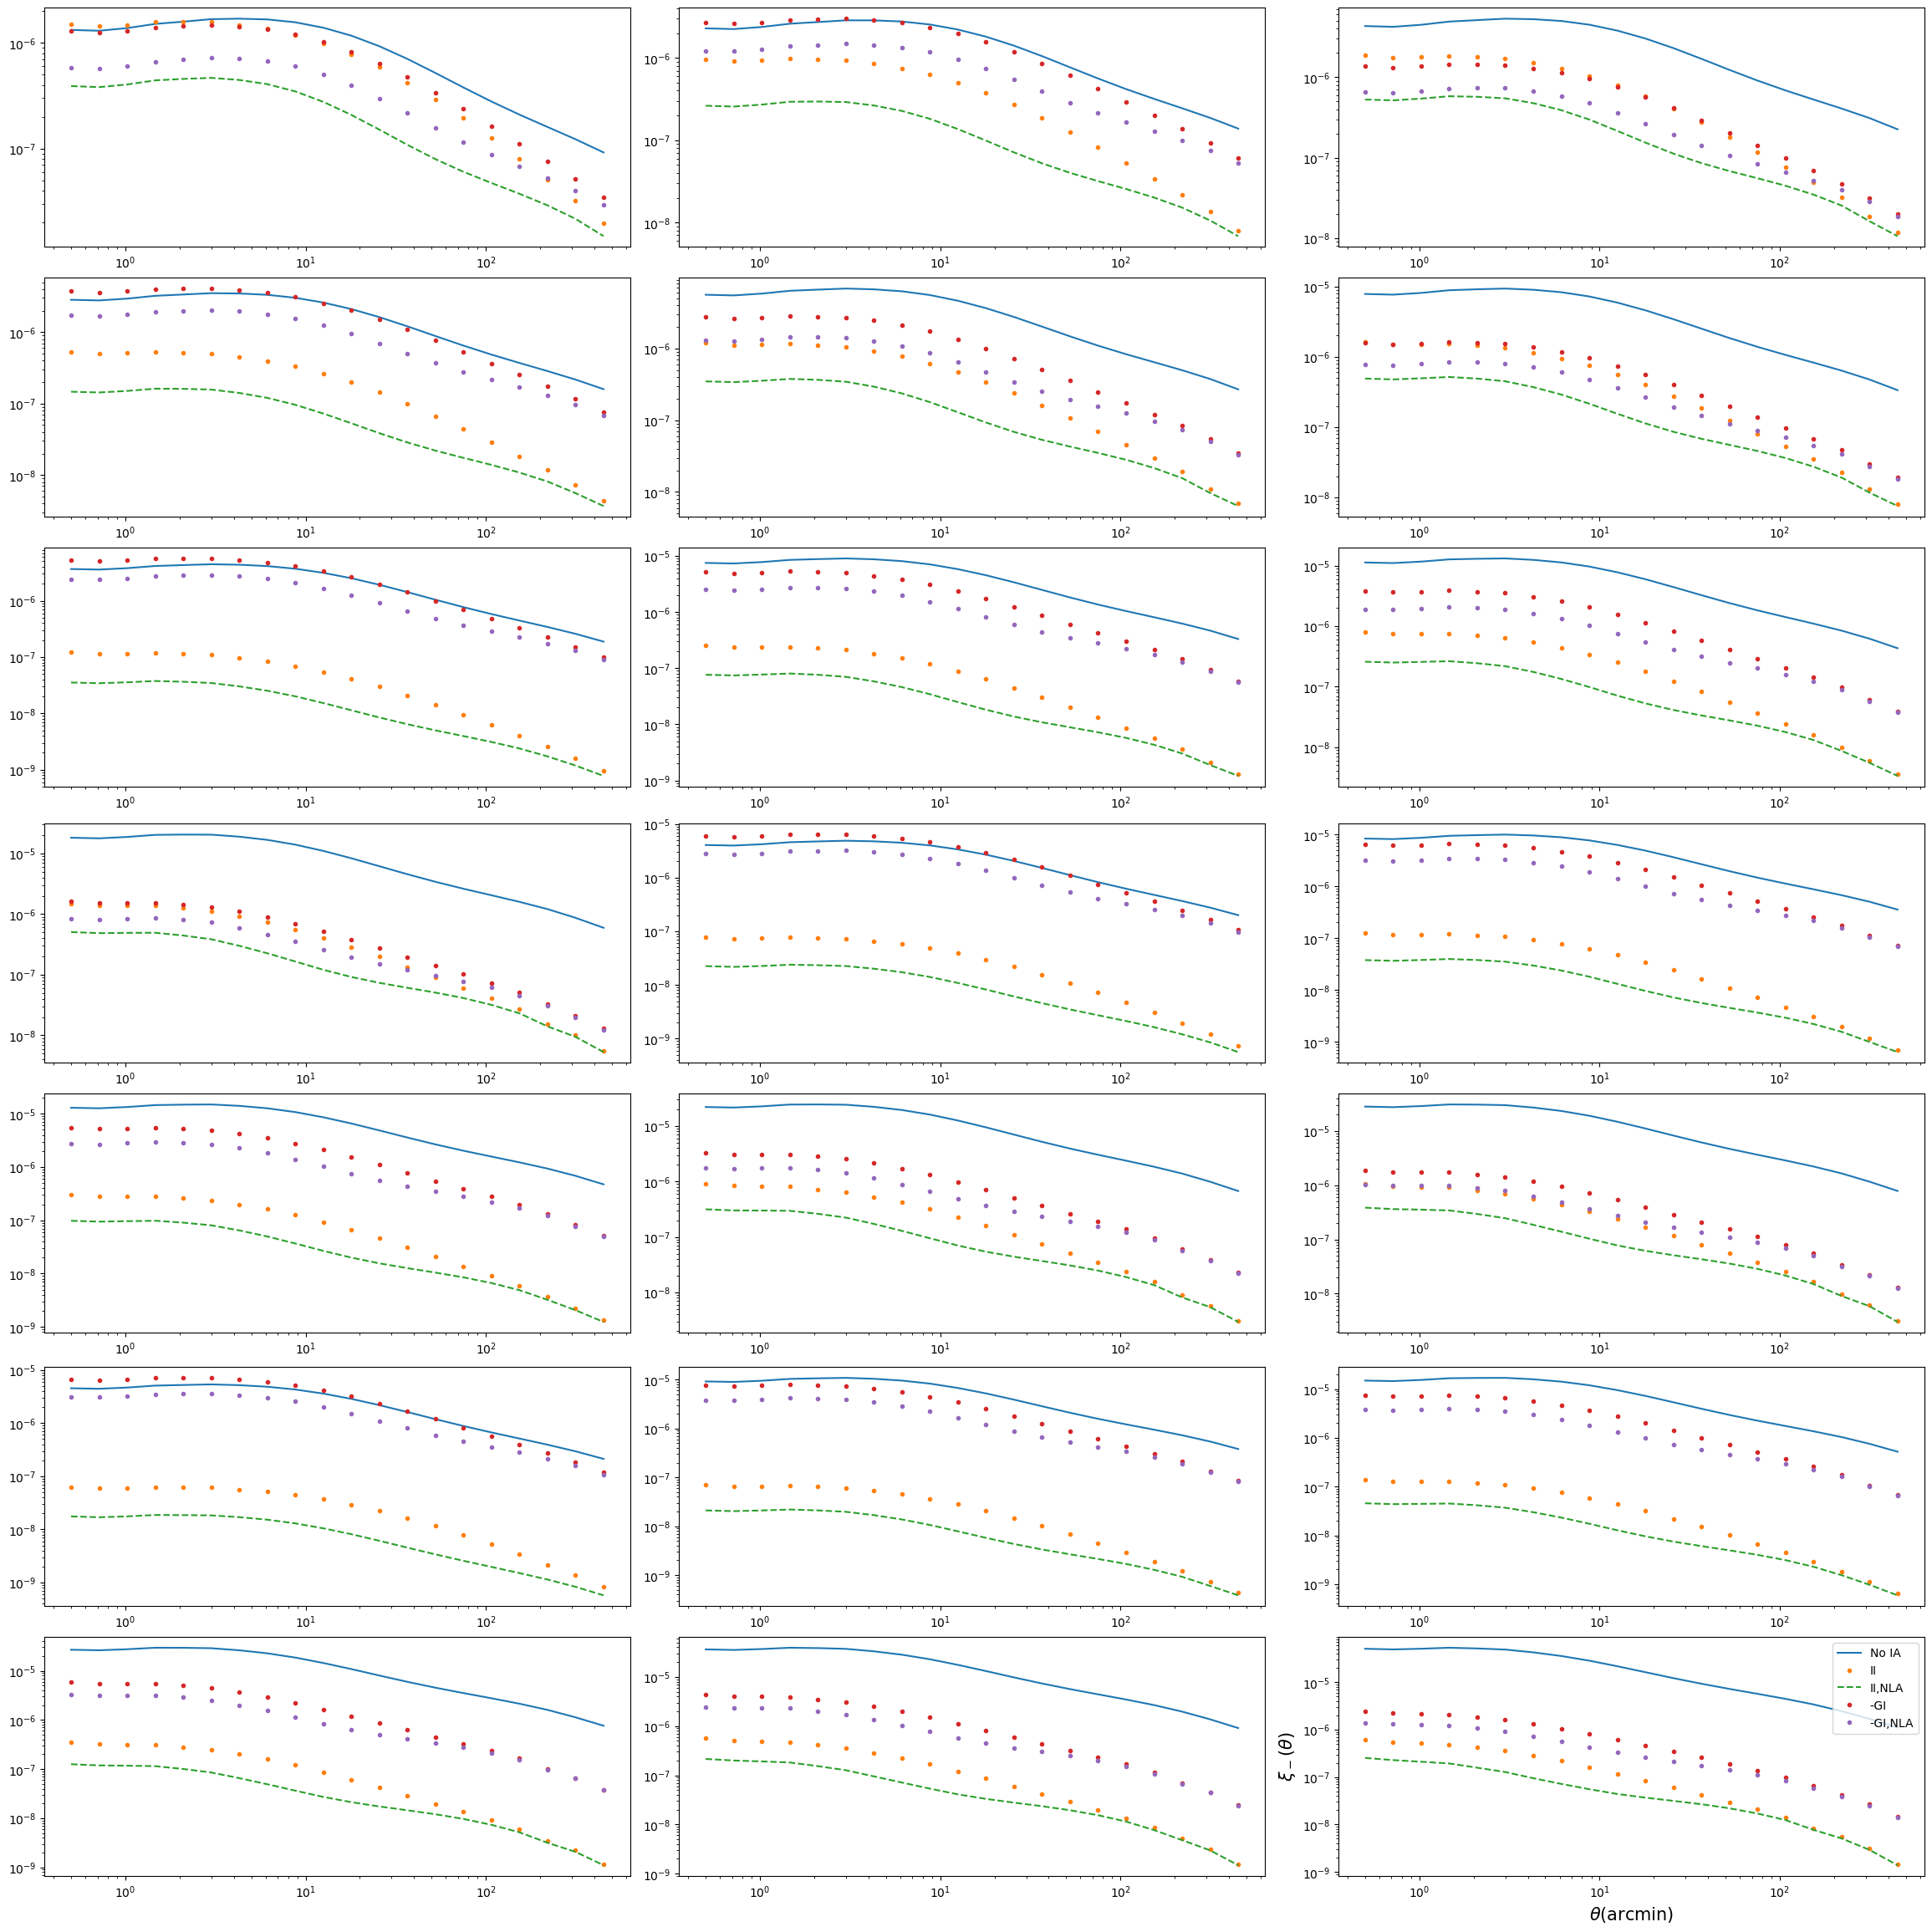

In [118]:

figsize = (23, 23)
fig =plt.figure(figsize=figsize, constrained_layout=True)
cols = 3
rows =nbins+1
axs = fig.subplots(rows, cols)
axs = trim_axs(axs, len(shear_GG_minus))

for ax, pi in zip(axs, shear_GG_minus):
    ax.loglog(theta_arc, pi,label='No IA')
for ax, pj in zip(axs, shear_II_minus):
    ax.loglog(theta_arc, pj,'.',label='II')
for ax, px in zip(axs, shear_II_NLA_minus):
    ax.loglog(theta_arc, px,'--',label='II,NLA')
for ax, pjk in zip(axs, shear_GI_minus):
    ax.loglog(theta_arc,-pjk,'.',label='-GI')
for ax, pjj in zip(axs, shear_GI_NLA_minus):
    ax.loglog(theta_arc, -pjj,'.',label='-GI,NLA')
plt.xlabel(r'$\theta$(arcmin)', fontsize=15)
plt.ylabel(r'$\xi_-(\theta)$', fontsize=15)

legend(loc='upper right')
#fig.savefig("neg_cross.png",dpi=250)

In [119]:
#names=('NO IA+','NO IA-','GI_NLA+','GI_NLA-','II_NLA+','II_NLA-','theta', 'bin_comb' )

In [ ]:


ellx=[]
for i in range(len(cls['GG'])):
    ellx.append(ell)

ell_tot=np.stack(ellx)

In [125]:
#Naming convention:
#theo_prediction_[AIA]_[b_TA]_[A2].fits

t = Table([shear_GG_plus,shear_GG_minus, shear_GI_plus,shear_GI_minus,shear_GI_NLA_plus,shear_GI_NLA_minus,shear_II_plus,shear_II_minus,shear_II_NLA_plus,shear_II_NLA_minus,theta,np.stack(index)], names=names)
#t = Table([shear_GG_plus,shear_GG_minus, shear_GI_NLA_plus,shear_GI_NLA_minus,shear_II_NLA_plus,shear_II_NLA_minus,theta,np.stack(index)], names=names)

#t.write('theory/CCL/theo_prediction_0.0_0.0_1.0_V2.fits', format='fits')
#t.write('theory/CCL/theo_prediction_1.0_1.0_1.0_cosmoSLICS_fid.fits', format='fits')
#t.write('theory/CCL/theo_prediction_1.0_1.0_0.0_cosmoSLICS_fid.fits', format='fits')
#t.write('theory/CCL/theo_prediction_1.0_0.0_0.0_cosmoSLICS_fid.fits', format='fits')
#t.write('theory/CCL/theo_prediction_1.0_2.0_0.0_cosmoSLICS_fid.fits', format='fits')
#t.write('theory/CCL/theo_prediction_1.0_0.5_0.0.fits', format='fits', overwrite=True)
#t.write('theory/CCL/theo_prediction_0.0_0.0_m1.0.fits', format='fits', overwrite=True)

#t.write('theory/CCL/theo_prediction_SRD_a1_1.0_bta_0.0_a2_0.0.fits', format='fits', overwrite=True)
#t.write('theory/CCL/theo_prediction_SRD_a1_m1.0_bta_0.0_a2_0.0.fits', format='fits', overwrite=True)
#t.write('theory/CCL/theo_prediction_SRD_HACC_a1_1.0_bta_1.0_a2_0.0.fits', format='fits', overwrite=True)
#t.write('theory/CCL/theo_prediction_SRD_HACC_a1_m1.0_bta_1.0_a2_0.0.fits', format='fits', overwrite=True)
#t.write('theory/CCL/theo_prediction_KiDS-Legacy_cosmoSLICS_a1_p1.0_bta_0.0_a2_0.0'+zcut_str+'.fits', format='fits', overwrite=True)
t.write('theory/CCL/theo_prediction_KiDS-Legacy_cosmoSLICS_a1_p1.0_bta_1.0_a2_0.0'+zcut_str+'.fits', format='fits', overwrite=True)
#t.write('theory/CCL/theo_prediction_KiDS-Legacy_cosmoSLICS_a1_p1.0_bta_1.0_a2_0.0'+zcut_str+'_9bins.fits', format='fits', overwrite=True)
#t.write('theory/CCL/theo_prediction_SRD_a1_1.0_bta_2.0_a2_0.0.fits', format='fits', overwrite=True)
#t.write('theory/CCL/theo_prediction_SRD_a1_0.0_bta_0.0_a2_1.0.fits', format='fits', overwrite=True)
#t.write('theory/CCL/theo_prediction_SRD_a1_0.0_bta_0.0_a2_m1.0.fits', format='fits', overwrite=True)
#t.write('theory/CCL/theo_prediction_SRD_NLAonly_a1_1.0.fits', format='fits', overwrite=True)




In [45]:
xip_flat = reshape(shear_GG_plus, [1,420])
xim_flat = reshape(shear_GG_minus, [1,420])
theta_flat = reshape(theta, [1,420])


In [46]:
result = np.zeros([420,2])
for i in range(420):
    result[i,0] = theta_flat[0,i]
    result[i,1] = xip_flat[0,i]

np.savetxt('theory/CCL/theo_xip_KiDS-Legacy_GG_cosmoSLICS_fid.dat',result)

result = np.zeros([420,2])
for i in range(420):
    result[i,0] = theta_flat[0,i]
    result[i,1] = xim_flat[0,i]

np.savetxt('theory/CCL/theo_xim_KiDS-Legacy_GG_cosmoSLICS_fid.dat',result)

In [107]:
#np.savetxt('theory/CCL/theo_prediction_KiDS-Legacy_GG_cosmoSLICS_fid.dat',result)

In [47]:
index

array([[1, 1],
       [2, 1],
       [2, 2],
       [3, 1],
       [3, 2],
       [3, 3],
       [4, 1],
       [4, 2],
       [4, 3],
       [4, 4],
       [5, 1],
       [5, 2],
       [5, 3],
       [5, 4],
       [5, 5],
       [6, 1],
       [6, 2],
       [6, 3],
       [6, 4],
       [6, 5],
       [6, 6]])

In [45]:
# Same, for C_ells here:
names_Cell=('NO IA','GI','GI_NLA','II','II_NLA','ell', 'bin_comb' )
t = Table([cls['GG'], cls['GI'],cls['GI,NLA'],cls['II'],cls['II,NLA'],ell_tot,np.stack(index)], names=names_Cell)
t.write('theory/CCL/cl_theo_prediction_SRD_HACC_a1_1.0_bta_1.0_a2_0.0.fits', format='fits', overwrite=True)

In [54]:
# define the lens samples
lens1 = ccl.WeakLensingTracer(cosmo, dndz=(z, nzs_s[0,:]))
lens2 = ccl.WeakLensingTracer(cosmo, dndz=(z, nzs_s[1,:]))
lens3 = ccl.WeakLensingTracer(cosmo, dndz=(z, nzs_s[2,:]))
lens4 = ccl.WeakLensingTracer(cosmo, dndz=(z, nzs_s[3,:]))
lens5 = ccl.WeakLensingTracer(cosmo, dndz=(z, nzs_s[4,:]))


In [ ]:
ia_tracer = ccl.WeakLensingTracer(cosmo,dndz = (z_arr, pz), has_shear=False, ia_bias = (z_arr, b_IA), use_A_ia=False)
# A tracer without shear but with A_ia, to plot the NLA-only contribution for comparison.
ia_NLA_tracer = ccl.WeakLensingTracer(cosmo,dndz = (z_arr, pz), has_shear=False, ia_bias = (z_arr, b_IA), use_A_ia=True)
# A weak gravitational lensing tracer for the GG and GI terms.
wl_tracer = ccl.WeakLensingTracer(cosmo,dndz = (z_arr, pz))


In [ ]:
cl_GI_NLA = ccl.angular_cl(cosmo, wl_tracer, ia_NLA_tracer, l_arr)
cl_II_NLA = ccl.angular_cl(cosmo, ia_NLA_tracer, ia_NLA_tracer, l_arr)
cl_GG = ccl.angular_cl(cosmo, wl_tracer, wl_tracer, l_arr)

In [50]:
xip_NLA = ccl.correlation(cosmo, ell=l_arr, C_ell=cl_GG+cl_GI_NLA+cl_II_NLA, theta=thetas/60, type='GG+')


<pyccl.cosmology.Cosmology>
	Neff    = 3.044
	Omega_b = 0.0448
	Omega_c = 0.22
	h       = 0.71
	n_s     = 0.963
	sigma8  = 0.801
	extra_parameters =
	HASH_ACCURACY_PARAMS = 0xa42c95dfd0a3ac70

In [3]:
import numpy as np
0.85*np.sqrt(0.3/0.225)

np.float64(0.9814954576223637)

In [84]:
cosmo

<pyccl.cosmology.Cosmology>
	Neff    = 3.044
	Omega_b = 0.0447
	Omega_c = 0.2458
	h       = 0.6898
	n_s     = 0.969
	sigma8  = 0.836450337410135
	extra_parameters =
	HASH_ACCURACY_PARAMS = 0xb0e2774a92009b77

In [86]:
pk_mm

<pyccl.pk2d.Pk2D>
	+==============+=================================================================+
	| a \ log10(k) | -5.00e+00 -4.95e+00 -4.90e+00 ...  2.90e+00  2.95e+00  3.00e+00 |
	+==============+=================================================================+
	|  1.00e-02    |  3.37e-02  3.77e-02  4.22e-02 ...  4.44e-10  3.27e-10  2.41e-10 |
	|  1.26e-02    |  5.46e-02  6.11e-02  6.83e-02 ...  7.01e-10  5.16e-10  3.80e-10 |
	|  1.58e-02    |  8.81e-02  9.86e-02  1.10e-01 ...  1.11e-09  8.18e-10  6.03e-10 |
	|     ...      |                               ...                               |
	|  9.54e-01    |  2.15e+02  2.40e+02  2.69e+02 ...  9.63e-04  7.49e-04  5.82e-04 |
	|  9.77e-01    |  2.20e+02  2.46e+02  2.75e+02 ...  1.03e-03  8.02e-04  6.24e-04 |
	|  1.00e+00    |  2.25e+02  2.52e+02  2.82e+02 ...  1.10e-03  8.58e-04  6.68e-04 |
	+==============+=================================================================+
	| is_log = False, extrap_orders = (1, 2)                 